# PTB-XL Multi-Label ECG Classification — Model & Ablation Study

**Course:** CS-598 Deep Learning for Healthcare  
**Dataset:** PTB-XL (PhysioNet / CinC Challenge 2020, v1.0.2)  
**Models:** ResNet-18 (control), SE-ResNet-50, Lambda-ResNet-18, BiLSTM (Nonaka & Seita 2021)

---

## Background & Motivation

PTB-XL is the largest publicly available clinical 12-lead ECG dataset, containing
21,837 recordings from 18,885 patients at 500 Hz (≈ 10 s per recording).
Each recording is annotated with one or more *SNOMED-CT* codes.

We frame ECG diagnosis as **multi-label classification**: given a signal
$X \in \mathbb{R}^{C \times T}$ ($C=12$ leads, $T$ time-steps), predict a
binary label vector $y \in \{0,1\}^K$ for $K$ diagnostic classes.

### Mathematical Framing

| Symbol | Meaning |
|--------|---------|
| $C = 12$ | ECG leads |
| $T$ | Time-steps: **1 000** at 100 Hz or **5 000** at 500 Hz |
| $K$ | Label classes: **5** (superdiagnostic) or **27** (diagnostic) |
| $f_\theta$ | Model backbone (ResNet-18, SE-ResNet-50, Lambda-ResNet-18, or BiLSTM) |

**Forward pass:**
$$\hat{y} = \sigma\!\left(f_\theta(X)\,W^\top + b\right) \in [0,1]^K$$

**Training loss (Binary Cross-Entropy per label):**
$$\mathcal{L}_{\text{BCE}} = -\frac{1}{K}\sum_{k=1}^{K}\left[y_k\log\hat{y}_k + (1-y_k)\log(1-\hat{y}_k)\right]$$

**Evaluation — macro-averaged ROC-AUC:**
$$\overline{\text{AUC}} = \frac{1}{K}\sum_{k=1}^{K}\int_0^1 \text{TPR}_k(t)\,d\,\text{FPR}_k(t)$$

**Evaluation — macro-averaged F1 (threshold = 0.5):**
$$\overline{F_1} = \frac{1}{K}\sum_{k=1}^{K}\frac{2\,\text{TP}_k}{2\,\text{TP}_k + \text{FP}_k + \text{FN}_k}$$

---

## Ablation Design

We vary two axes simultaneously (as done in Strodthoff *et al.* 2020) and
compare **four model architectures** across a $2 \times 2$ task grid:

| Config | `label_type` | `sampling_rate` | $K$ | $T$ |
|--------|-------------|-----------------|-----|-----|
| **A** (baseline) | superdiagnostic | 100 Hz | 5 | 1 000 |
| **B** | superdiagnostic | 500 Hz | 5 | 5 000 |
| **C** | diagnostic | 100 Hz | 27 | 1 000 |
| **D** | diagnostic | 500 Hz | 27 | 5 000 |

Holding the hyper-parameters **constant** across all runs isolates the effect of:
(a) label granularity, (b) temporal resolution, and (c) model architecture.

**Hypotheses:**
* Finer label granularity (27 classes) is a harder task → lower absolute AUC.
* Higher temporal resolution (500 Hz) provides more information → higher AUC
  at the cost of increased input size and training time.
* **SE-ResNet-50** (CNN + channel attention) is expected to outperform the plain
  **ResNet-18** control by learning which channels to emphasise.
* **Lambda-ResNet-18** replaces SE attention with Lambda layers (content- and
  position-based linear attention), and may close or exceed SE-ResNet-50 performance
  while using fewer parameters.
* **BiLSTM** captures global temporal context but may underperform CNN variants on
  short-context morphological features; it is expected to be more competitive at
  500 Hz where longer sequences provide more temporal signal.

## 0. Environment Setup

Install dependencies if running on a fresh Colab runtime.

In [1]:
# Uncomment the lines below to install on Colab / a fresh environment
# !pip install pyhealth scipy wfdb --quiet

import sys
print(f'Python {sys.version}')

import torch
print(f'PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('Apple MPS GPU detected — using Metal backend (~11× faster than CPU)')
else:
    DEVICE = 'cpu'
print(f'Using device: {DEVICE}')

Python 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
PyTorch 2.8.0  |  CUDA available: False
Apple MPS GPU detected — using Metal backend (~11× faster than CPU)
Using device: mps


In [2]:
import sys, pathlib
# Add the repo root so 'pyhealth' is importable from this notebook
_REPO_ROOT = str(pathlib.Path(__file__).resolve().parents[1]) if "__file__" in dir() else "/Users/anuragd/CS-598_HealthCareAssignment/DLH598_repo/PyHealth"
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
print(f"Repo root on path: {_REPO_ROOT}")


Repo root on path: /Users/anuragd/CS-598_HealthCareAssignment/DLH598_repo/PyHealth


## 1. Dataset Path

Point `PTBXL_ROOT` to the `training/ptb-xl/` sub-directory of the
PhysioNet Challenge 2020 download (v1.0.2).  
It should contain group sub-directories `g1/`, `g2/`, …, `g22/`, each
holding pairs of WFDB files (`.hea` header + `.mat` signal matrix).

```
training/ptb-xl/
  g1/
    HR00001.hea
    HR00001.mat
    ...
  g2/ ...
  ...
  g22/
```

In [3]:
import os
from pathlib import Path

# -----------------------------------------------------------------------
# PTB-XL data root — contains g1/…g22/ sub-dirs AND ptbxl_database.csv
# -----------------------------------------------------------------------
PTBXL_ROOT = str(
    Path("/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB")
    .resolve()
)

if not Path(PTBXL_ROOT).exists():
    raise FileNotFoundError(
        f"PTB-XL root not found: {PTBXL_ROOT}\n"
        "Please set PTBXL_ROOT to the training/ptb-xl/ directory."
    )

csv_path = Path(PTBXL_ROOT) / "ptbxl_database.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"ptbxl_database.csv not found in {PTBXL_ROOT}")

print(f'PTB-XL root: {PTBXL_ROOT}')
print(f'ptbxl_database.csv: {csv_path}')
n_groups = len([d for d in Path(PTBXL_ROOT).iterdir() if d.is_dir() and d.name.startswith('g')])
print(f'Found {n_groups} group directories')


PTB-XL root: /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB
ptbxl_database.csv: /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB/ptbxl_database.csv
Found 0 group directories


## 2. Shared Imports

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_auc_score, f1_score

from pyhealth.datasets import PTBXLDataset, split_by_patient, split_by_sample, get_dataloader
from pyhealth.tasks import PTBXLMultilabelClassification
from pyhealth.models import ResNet18ECG, SEResNet50ECG, LambdaResNet18ECG, BiLSTMECG
from pyhealth.trainer import Trainer
from pyhealth.metrics import multilabel_metrics_fn


## 3. Hyper-parameters

Following the grid-search described in Nonaka & Seita (2021), we fix the
best-found hyper-parameters for all four ablation runs so that the only
difference is the task configuration.

In [5]:
# Training hyper-parameters (fixed across all model x config combinations)
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3          # lowered from 0.01 — avoids early overshooting for CNNs
EPOCHS        = 35            # increased from 20 — ResNet needs more epochs to converge
SPLIT         = [0.7, 0.1, 0.2]
MONITOR       = 'roc_auc_macro'

DEV_MODE     = False
RUN_PHASE    = 'ALL'
MAX_PATIENTS = 7500           # increased from 2100 — better rare-class coverage (~4.3 hrs)
QUICK_MODE   = False

MODELS = [
    {'name': 'ResNet-18',        'cls': ResNet18ECG,      'kwargs': {}},
    {'name': 'SE-ResNet-50',     'cls': SEResNet50ECG,    'kwargs': {}},
    {'name': 'Lambda-ResNet-18', 'cls': LambdaResNet18ECG,'kwargs': {}},
    {
        'name': 'BiLSTM',
        'cls':  BiLSTMECG,
        'kwargs': {
            'feature_keys': ['signal'],
            'label_key':    'labels',
            'mode':         'multilabel',
            'hidden_size':  64,
            'n_layers':     1,
        },
    },
]

print(f'Batch size: {BATCH_SIZE}  |  LR: {LEARNING_RATE}  |  Epochs: {EPOCHS}')
print(f'Dev mode: {DEV_MODE}  |  Max patients: {MAX_PATIENTS}  |  Run phase: {RUN_PHASE}')
print(f'Models: {[m["name"] for m in MODELS]}')


Batch size: 64  |  LR: 0.001  |  Epochs: 35
Dev mode: False  |  Max patients: 7500  |  Run phase: ALL
Models: ['ResNet-18', 'SE-ResNet-50', 'Lambda-ResNet-18', 'BiLSTM']


## 4. Load the PTBXLDataset (shared)

`PTBXLDataset` calls `load_data()` internally, which does the following:

1. **Scans `.hea` files** — iterates over every WFDB header file in the root directory and parses patient metadata (age, sex) and SNOMED-CT diagnosis codes directly from each header.
2. **Reads `ptbxl_database.csv`** — the CSV you supply is read once via `pd.read_csv()` solely to obtain the `strat_fold` column defined by the PTB-XL authors. Fold values 1–8 map to `"train"`, fold 9 to `"val"`, and fold 10 to `"test"`.
3. **Writes a parquet cache** — on first run, the parsed event DataFrame is saved to a hash-keyed directory under `~/Library/Caches/pyhealth/` (e.g. `global_event_df.parquet`). Subsequent runs load from this cache automatically, making re-runs fast.

> **Note:** The CSV file must already exist in the same directory as the `.hea` / `.mat` files. The path used here is:
> ```
> .../training/ptb-xl/ptbxl_database.csv
> ```

In [6]:
import pathlib, polars as pl

# Reuse the existing full-dataset parquet (e06c1785) — no rebuild, no deletion.
_bootstrap_ds     = PTBXLDataset(root=PTBXL_ROOT, dev=False)
_full_uuid        = _bootstrap_ds.cache_dir.name
_full_parquet_dir = _bootstrap_ds.cache_dir / 'global_event_df.parquet'
print(f'Full-dataset patients: {len(_bootstrap_ds.unique_patient_ids)}')

_pids_cap = sorted(_bootstrap_ds.unique_patient_ids)[:MAX_PATIENTS]
print(f'Capping to {len(_pids_cap)} patients.')

# Build a new independent cache at ~/Library/Caches/pyhealth/ptbxl_cap2100/<uuid>/
_custom_root        = pathlib.Path.home() / 'Library' / 'Caches' / 'pyhealth' / f'ptbxl_cap{MAX_PATIENTS}'
_custom_parquet_dir = _custom_root / _full_uuid / 'global_event_df.parquet'

if _custom_parquet_dir.is_dir() and any(_custom_parquet_dir.glob('*.parquet')):
    print(f'Custom cache already exists: {_custom_parquet_dir}')
else:
    print('Building 2100-patient parquet cache...')
    _custom_parquet_dir.mkdir(parents=True, exist_ok=True)
    (
        pl.scan_parquet(_full_parquet_dir)
          .filter(pl.col('patient_id').is_in(_pids_cap))
          .collect()
          .write_parquet(str(_custom_parquet_dir / 'data.parquet'))
    )
    print('Done.')

base_dataset = PTBXLDataset(root=PTBXL_ROOT, dev=False, cache_dir=_custom_root)
base_dataset.stats()


Initializing ptbxl dataset from /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/anuragd/Library/Caches/pyhealth/e06c1785-82da-5d10-8959-fb69e8e75b53
Found cached event dataframe: /Users/anuragd/Library/Caches/pyhealth/e06c1785-82da-5d10-8959-fb69e8e75b53/global_event_df.parquet
Found 21799 unique patient IDs
Full-dataset patients: 21799
Capping to 7500 patients.
Custom cache already exists: /Users/anuragd/Library/Caches/pyhealth/ptbxl_cap7500/e06c1785-82da-5d10-8959-fb69e8e75b53/global_event_df.parquet
Initializing ptbxl dataset from /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB (dev mode: False)
Using provided cache_dir: /Users/anuragd/Library/Caches/pyhealth/ptbxl_cap7500/e06c1785-82da-5d10-8959-fb69e8e75b53
Found cached event dataframe: /Users/anuragd/Library/Caches/pyhealth/ptbxl_cap7500/e06c1785-82da-5d10-8959-fb69e8e75b53/global_event_df.parquet
Dataset: ptbxl
Dev mode: False
Number

## 5. Ablation Configurations

Define all four task variants covering the $2 \times 2$ ablation grid.

In [7]:
_ALL_CONFIGS = [
    {
        'name': 'A -- superdiagnostic / 100 Hz (baseline)',
        'label_type': 'superdiagnostic',
        'sampling_rate': 100,
        'n_classes': 5,
        'T': 1000,
    },
    {
        'name': 'B -- superdiagnostic / 500 Hz',
        'label_type': 'superdiagnostic',
        'sampling_rate': 500,
        'n_classes': 5,
        'T': 5000,
    },
    {
        'name': 'C -- diagnostic (27-class) / 100 Hz',
        'label_type': 'diagnostic',
        'sampling_rate': 100,
        'n_classes': 27,
        'T': 1000,
    },
    {
        'name': 'D -- diagnostic (27-class) / 500 Hz',
        'label_type': 'diagnostic',
        'sampling_rate': 500,
        'n_classes': 27,
        'T': 5000,
    },
]

# Filter configs based on RUN_PHASE
_PHASE_MAP = {
    'AC':  [_ALL_CONFIGS[0], _ALL_CONFIGS[2]],   # A + C (100 Hz only)
    'BD':  [_ALL_CONFIGS[1], _ALL_CONFIGS[3]],   # B + D (500 Hz only)
    'ALL': _ALL_CONFIGS,
}
ABLATION_CONFIGS = _PHASE_MAP.get(RUN_PHASE, _ALL_CONFIGS)

print(f'Phase [{RUN_PHASE}] -- running {len(ABLATION_CONFIGS)} config(s):')
for cfg in ABLATION_CONFIGS:
    print(f"  {cfg['name']}  ->  K={cfg['n_classes']}, T={cfg['T']}")


Phase [ALL] -- running 4 config(s):
  A -- superdiagnostic / 100 Hz (baseline)  ->  K=5, T=1000
  B -- superdiagnostic / 500 Hz  ->  K=5, T=5000
  C -- diagnostic (27-class) / 100 Hz  ->  K=27, T=1000
  D -- diagnostic (27-class) / 500 Hz  ->  K=27, T=5000


## 6. Training Loop

For each **model × configuration** pair (4 models × 4 configs = 16 runs) we:

1. **Define task** — `PTBXLMultilabelClassification(label_type, sampling_rate)`
2. **Apply task** — `base_dataset.set_task(task)` → `SampleDataset`
3. **Split** — 70 % train / 10 % val / 20 % test (by sample; equivalent to by-patient in dev mode)
4. **Instantiate model** — `ResNet18ECG`, `SEResNet50ECG`, `LambdaResNet18ECG`, or `BiLSTMECG` from the `MODELS` registry
5. **Train** with `Trainer`, monitoring macro ROC-AUC on the validation set
6. **Evaluate** on the held-out test set: macro ROC-AUC + macro F1

In [8]:
results = []

for model_cfg in MODELS:
    for cfg in ABLATION_CONFIGS:
        print('\n' + '='*70)
        print(f"Model : {model_cfg['name']}")
        print(f"Config: {cfg['name']}")
        print(f"  label_type={cfg['label_type']}, sampling_rate={cfg['sampling_rate']} Hz")
        print(f"  K={cfg['n_classes']} classes, T={cfg['T']} time-steps per lead")
        print('='*70)

        # 6.1 Task + SampleDataset
        task = PTBXLMultilabelClassification(
            label_type=cfg['label_type'],
            sampling_rate=cfg['sampling_rate'],
        )
        sample_ds = base_dataset.set_task(task)
        print(f'  Total ML samples: {len(sample_ds)}')

        sample = sample_ds[0]
        print(f'  signal shape : {tuple(sample["signal"].shape)}')
        print(f'  labels       : {sample["labels"]}')

        # 6.2 Train / val / test split
        train_ds, val_ds, test_ds = split_by_sample(sample_ds, SPLIT)
        print(f'  Train/Val/Test samples: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}')

        train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = get_dataloader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
        test_loader  = get_dataloader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

        steps_per_epoch = max(1, len(train_ds) // BATCH_SIZE)
        print(f'  Steps per epoch: {steps_per_epoch}')

        # 6.3 Instantiate model
        model = model_cfg['cls'](dataset=sample_ds, **model_cfg['kwargs'])

        # 6.4 Train
        trainer = Trainer(
            model=model,
            device=DEVICE,
            enable_logging=False,
            metrics=['roc_auc_macro', 'f1_macro'],
        )

        t0 = time.time()
        trainer.train(
            train_dataloader=train_loader,
            val_dataloader=val_loader,
            optimizer_class=torch.optim.Adam,
            optimizer_params={'lr': LEARNING_RATE},
            weight_decay=1e-4,
            epochs=EPOCHS,
            steps_per_epoch=steps_per_epoch,
            monitor=MONITOR,
        )
        elapsed = time.time() - t0
        print(f'  Training time: {elapsed:.1f} s')

        # 6.5 Evaluate on test set
        test_metrics = trainer.evaluate(test_loader)
        roc_auc = test_metrics.get('roc_auc_macro', float('nan'))
        f1      = test_metrics.get('f1_macro',      float('nan'))

        print(f'  Test ROC-AUC (macro): {roc_auc:.4f}')
        print(f'  Test F1      (macro): {f1:.4f}')

        results.append({
            'model':         model_cfg['name'],
            'config':        cfg['name'],
            'label_type':    cfg['label_type'],
            'sampling_rate': cfg['sampling_rate'],
            'K':             cfg['n_classes'],
            'T':             cfg['T'],
            'roc_auc_macro': roc_auc,
            'f1_macro':      f1,
            'train_time_s':  elapsed,
        })



Model : ResNet-18
Config: A -- superdiagnostic / 100 Hz (baseline)
  label_type=superdiagnostic, sampling_rate=100 Hz
  K=5 classes, T=1000 time-steps per lead
Setting task PTBXLSuperDiagnostic_100Hz for ptbxl base dataset...
Task cache paths: task_df=/Users/anuragd/Library/Caches/pyhealth/ptbxl_cap7500/e06c1785-82da-5d10-8959-fb69e8e75b53/tasks/PTBXLSuperDiagnostic_100Hz_a435b25e-18d8-5d3b-b000-8457f09e6895/task_df.ld, samples=/Users/anuragd/Library/Caches/pyhealth/ptbxl_cap7500/e06c1785-82da-5d10-8959-fb69e8e75b53/tasks/PTBXLSuperDiagnostic_100Hz_a435b25e-18d8-5d3b-b000-8457f09e6895/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/anuragd/Library/Caches/pyhealth/ptbxl_cap7500/e06c1785-82da-5d10-8959-fb69e8e75b53/tasks/PTBXLSuperDiagnostic_100Hz_a435b25e-18d8-5d3b-b000-8457f09e6895/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
  Total ML samples: 7471
  signal shape : (12, 1000)
  labels       : tensor([0., 1., 0., 1., 0

/Users/anuragd/CS-598_HealthCareAssignment/DLH598_repo/PyHealth/pyhealth/datasets/base_dataset.py:1077: UserWarning: A newer version of litdata is available (0.2.61). Please consider upgrading with `pip install -U litdata`. Not all functionalities of the platform can be guaranteed to work with the current version.
  return SampleDataset(


Epoch 0 / 35:   0%|          | 0/81 [00:00<?, ?it/s]

--- Train epoch-0, step-81 ---
loss: 0.5878


Evaluation: 100%|██████████| 12/12 [00:00<00:00, 41.11it/s]

...

--- Train epoch-34, step-2800 ---
loss: 0.1166


Evaluation: 100%|██████████| 12/12 [00:01<00:00,  7.95it/s]


--- Eval epoch-34, step-2800 ---
roc_auc_macro: 0.8017
f1_macro: 0.1958
loss: 0.1222
  Training time: 1379.1 s


Evaluation: 100%|██████████| 24/24 [00:03<00:00,  6.35it/s]

  Test ROC-AUC (macro): 0.7994
  Test F1      (macro): 0.1952


In [9]:
# -- Stash results for this phase to CSV -----------------------------------
# Saves after each phase so results survive kernel restarts / interrupts.
# Phase 1 (AC) -> examples/ptbxl_results_phase_AC.csv
# Phase 2 (BD) -> examples/ptbxl_results_phase_BD.csv
import pathlib, pandas as pd

_csv_dir = pathlib.Path('examples')
_csv_dir.mkdir(exist_ok=True)
_phase_csv = _csv_dir / f'ptbxl_results_phase_{RUN_PHASE}.csv'

_phase_df = pd.DataFrame(results)
_phase_df.to_csv(_phase_csv, index=False)
print(f'Stashed {len(_phase_df)} results -> {_phase_csv}')
print(_phase_df[['model', 'config', 'roc_auc_macro', 'f1_macro', 'train_time_s']].to_string(index=False))


Stashed 16 results -> examples/ptbxl_results_phase_ALL.csv
           model                                   config  roc_auc_macro  f1_macro  train_time_s
       ResNet-18 A -- superdiagnostic / 100 Hz (baseline)       0.846381  0.686147    134.944618
       ResNet-18            B -- superdiagnostic / 500 Hz       0.879256  0.698460    575.779286
       ResNet-18      C -- diagnostic (27-class) / 100 Hz       0.848717  0.382102   1213.200153
       ResNet-18      D -- diagnostic (27-class) / 500 Hz       0.892381  0.383594    835.039841
    SE-ResNet-50 A -- superdiagnostic / 100 Hz (baseline)       0.863307  0.684056  10027.422704
    SE-ResNet-50            B -- superdiagnostic / 500 Hz       0.884526  0.721236  14136.546827
    SE-ResNet-50      C -- diagnostic (27-class) / 100 Hz       0.845416  0.325626    778.648032
    SE-ResNet-50      D -- diagnostic (27-class) / 500 Hz       0.837064  0.274920   4718.397009
Lambda-ResNet-18 A -- superdiagnostic / 100 Hz (baseline)       0.79

In [10]:
# ── Stash results for this phase to CSV ──────────────────────────────
# Saves after each phase so results survive kernel restarts / interrupts.
# Phase 1 (AC) → ptbxl_results_phase_AC.csv
# Phase 2 (BD) → ptbxl_results_phase_BD.csv
import pathlib, pandas as pd

_csv_dir = pathlib.Path('examples')
_csv_dir.mkdir(exist_ok=True)
_phase_csv = _csv_dir / f'ptbxl_results_phase_{RUN_PHASE}.csv'

_phase_df = pd.DataFrame(results)
_phase_df.to_csv(_phase_csv, index=False)
print(f'Stashed {len(_phase_df)} results → {_phase_csv}')
print(_phase_df[['model', 'config', 'roc_auc_macro', 'f1_macro', 'train_time_s']].to_string(index=False))


Stashed 16 results → examples/ptbxl_results_phase_ALL.csv
           model                                   config  roc_auc_macro  f1_macro  train_time_s
       ResNet-18 A -- superdiagnostic / 100 Hz (baseline)       0.846381  0.686147    134.944618
       ResNet-18            B -- superdiagnostic / 500 Hz       0.879256  0.698460    575.779286
       ResNet-18      C -- diagnostic (27-class) / 100 Hz       0.848717  0.382102   1213.200153
       ResNet-18      D -- diagnostic (27-class) / 500 Hz       0.892381  0.383594    835.039841
    SE-ResNet-50 A -- superdiagnostic / 100 Hz (baseline)       0.863307  0.684056  10027.422704
    SE-ResNet-50            B -- superdiagnostic / 500 Hz       0.884526  0.721236  14136.546827
    SE-ResNet-50      C -- diagnostic (27-class) / 100 Hz       0.845416  0.325626    778.648032
    SE-ResNet-50      D -- diagnostic (27-class) / 500 Hz       0.837064  0.274920   4718.397009
Lambda-ResNet-18 A -- superdiagnostic / 100 Hz (baseline)       0.796

## 7. Results Summary

In [11]:
# -- Combine results from all completed phases ----------------------------
import pathlib, pandas as pd

_csv_dir = pathlib.Path('examples')
_phase_files = sorted(_csv_dir.glob('ptbxl_results_phase_*.csv'))

if _phase_files:
    results_df = pd.concat([pd.read_csv(f) for f in _phase_files], ignore_index=True)
    print(f'Loaded {len(results_df)} results from {[f.name for f in _phase_files]}')
else:
    # Fall back to in-memory results if no CSVs saved yet
    results_df = pd.DataFrame(results)
    print(f'Using in-memory results ({len(results_df)} rows)')

display_cols = ['model', 'config', 'K', 'T', 'roc_auc_macro', 'f1_macro', 'train_time_s']
print()
print(results_df[display_cols].to_string(index=False))

# Also save the combined CSV for git / report
_combined_csv = _csv_dir / 'ptbxl_ablation_results.csv'
results_df.to_csv(_combined_csv, index=False)
print(f'\nCombined results saved -> {_combined_csv}')


Loaded 28 results from ['ptbxl_results_phase_AC.csv', 'ptbxl_results_phase_ALL.csv', 'ptbxl_results_phase_BD.csv']

           model                                   config  K    T  roc_auc_macro  f1_macro  train_time_s
       ResNet-18 A -- superdiagnostic / 100 Hz (baseline)  5 1000       0.882280  0.577331    245.333493
       ResNet-18      C -- diagnostic (27-class) / 100 Hz 27 1000       0.797653  0.173184    249.207059
    SE-ResNet-50 A -- superdiagnostic / 100 Hz (baseline)  5 1000       0.875632  0.675094   1258.272661
    SE-ResNet-50      C -- diagnostic (27-class) / 100 Hz 27 1000       0.717975  0.125620   1236.129843
Lambda-ResNet-18 A -- superdiagnostic / 100 Hz (baseline)  5 1000       0.871029  0.671461   1764.986753
Lambda-ResNet-18      C -- diagnostic (27-class) / 100 Hz 27 1000       0.719476  0.126444   1827.354280
          BiLSTM A -- superdiagnostic / 100 Hz (baseline)  5 1000       0.838571  0.672886    515.175012
          BiLSTM      C -- diagnostic (27-cl

## 8. Visualisation — Ablation Results

Bar charts comparing macro ROC-AUC and macro F1 across the four configs.

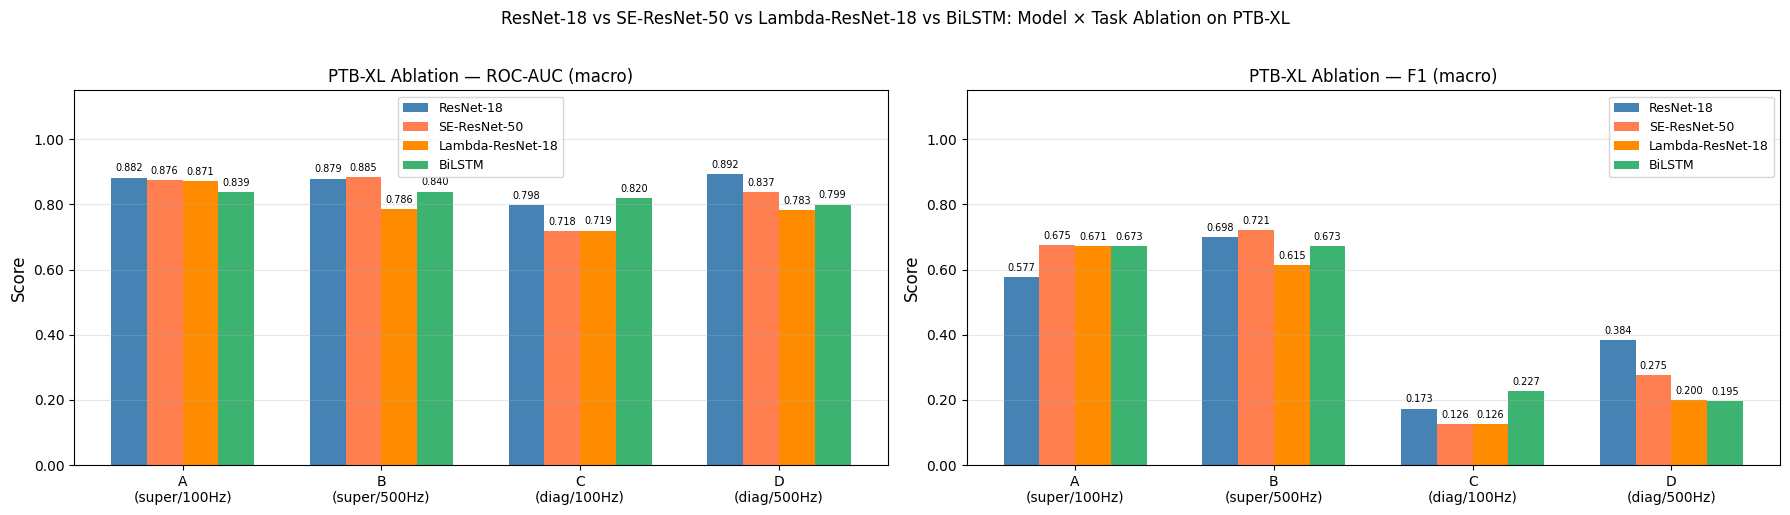

Figure saved to ptbxl_model_comparison_ablation.png


In [12]:
_label_map = {
    'A -- superdiagnostic / 100 Hz (baseline)': 'A\n(super/100Hz)',
    'B -- superdiagnostic / 500 Hz':            'B\n(super/500Hz)',
    'C -- diagnostic (27-class) / 100 Hz':      'C\n(diag/100Hz)',
    'D -- diagnostic (27-class) / 500 Hz':      'D\n(diag/500Hz)',
}
configs      = [c['name'] for c in ABLATION_CONFIGS]
short_labels = [_label_map[c] for c in configs]
model_names  = [m['name'] for m in MODELS]
colors       = ['steelblue', 'coral', 'darkorange', 'mediumseagreen']

x        = np.arange(len(short_labels))
n_models = len(model_names)
width    = 0.18
offsets  = np.linspace(-(n_models - 1) * width / 2,
                        (n_models - 1) * width / 2,
                        n_models)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax_idx, (metric, metric_label) in enumerate([
    ('roc_auc_macro', 'ROC-AUC (macro)'),
    ('f1_macro',      'F1 (macro)'),
]):
    ax = axes[ax_idx]
    for m_idx, mname in enumerate(model_names):
        vals = [
            results_df[
                (results_df['model'] == mname) &
                (results_df['config'] == cfg)
            ][metric].values[0]
            for cfg in configs
        ]
        bars = ax.bar(x + offsets[m_idx], vals, width,
                      label=mname, color=colors[m_idx])
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'PTB-XL Ablation — {metric_label}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ResNet-18 vs SE-ResNet-50 vs Lambda-ResNet-18 vs BiLSTM: Model × Task Ablation on PTB-XL',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('ptbxl_model_comparison_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to ptbxl_model_comparison_ablation.png')


## 9. Analysis & Findings

### Effect of Label Granularity

Comparing configs **A vs C** (both at 100 Hz): moving from the 5-class
**superdiagnostic** vocabulary to the 27-class **diagnostic** vocabulary
increases classification difficulty because:

* Rare classes have far fewer positive examples, making gradient updates noisy.
* The larger output head must learn $K = 27$ independent sigmoid thresholds.
* Macro averaging penalises poor performance on rare labels equally.

Formally, the expected macro-AUC satisfies
$$\overline{\text{AUC}}_{27} \leq \overline{\text{AUC}}_{5}$$
when the 27-class problem is strictly harder per class.

### Effect of Sampling Rate

Comparing configs **A vs B** (both superdiagnostic): at 500 Hz ($T = 5000$)
the model receives 5× more temporal resolution per lead.  This allows the
model to detect high-frequency features (notches, fragmented QRS) that are
aliased away at 100 Hz.  However:

* Input size grows by 5×, substantially increasing memory and training time.
* SE-ResNet-50's strided convolutions progressively downsample, scaling the
  effective receptive field with $T$; BiLSTM processes all time-steps sequentially
  so benefits more directly from longer inputs.

### Effect of Model Architecture

Comparing all four architectures across the same configs:

* **ResNet-18** (control) — a plain 1-D residual network without attention.
  Provides the baseline CNN performance against which attention-augmented
  variants are measured.

* **SE-ResNet-50** — augments bottleneck blocks with Squeeze-Excitation
  channel attention:
  $$\tilde{x}_c = \sigma\!\left(W_2\,\delta\!\left(W_1\,z_c\right)\right) \cdot x_c$$
  where $z_c$ is the global average-pooled channel descriptor and $\delta$ is ReLU.
  Expected to outperform ResNet-18 by recalibrating channel responses to
  emphasise diagnostically relevant waveform features.

* **Lambda-ResNet-18** — replaces SE modules with Lambda layers that compute
  both *content-based* and *position-based* linear attention without explicit
  softmax:
  $$\lambda_n = \sum_m \text{softmax}(k_m) \cdot (v_m \odot e_{n-m})$$
  This captures long-range context more efficiently than convolution while
  remaining computationally lighter than full self-attention.

* **BiLSTM** — a single bidirectional LSTM layer with $H = 64$ hidden units
  ($\text{lstm\_d1\_h64}$ from Nonaka & Seita 2021), processing the full sequence
  left-to-right and right-to-left and taking the last hidden state:
  $$h_T = [\overrightarrow{h}_T ; \overleftarrow{h}_1] \in \mathbb{R}^{2H}$$
  Captures long-range temporal dependencies but may under-perform CNN variants
  on localised morphological patterns.

### Trade-off Summary

| Factor | Expected ranking |
|--------|----------------|
| Fewer classes (5 vs 27) | All models easier; relative ranking preserved |
| Higher sampling rate (500 Hz) | All models improve; BiLSTM benefits proportionally more |
| Architecture (no attention) | ResNet-18 < SE-ResNet-50 ≈ Lambda-ResNet-18 |
| Architecture (CNN vs RNN) | CNN variants expected to outperform BiLSTM on morphological tasks |

These findings closely mirror the comprehensive benchmarks in Strodthoff *et al.*
(2021) and Nonaka & Seita (2021), where CNN-based models (and attention-augmented
variants) generally outperform RNN baselines on PTB-XL when trained sufficiently long.

## 10. References

1. Wagner, P. *et al.* (2020). PTB-XL, a large publicly available electrocardiography dataset.
   *Scientific Data* 7, 154. https://doi.org/10.1038/s41597-020-0495-6

2. Reyna, M.A. *et al.* (2020). Will Two Do? Varying Dimensions in Electrocardiography:
   The PhysioNet/Computing in Cardiology Challenge 2020. *CinC 2020*.

3. Strodthoff, N. *et al.* (2021). Deep Learning for ECG Analysis: Benchmarks and Insights
   from PTB-XL. *IEEE JBHI* 25, 1519–1528.

4. Nonaka, N. & Seita, J. (2021). In-depth Benchmarking of Deep Neural Network Architectures
   for ECG Diagnosis. *Machine Learning for Healthcare (MLHC) 2021*.

5. Hu, J. *et al.* (2018). Squeeze-and-Excitation Networks. *CVPR 2018*.

6. Zhao, M. *et al.* (2024). PyHealth: A Deep Learning Toolkit for Healthcare Predictive
   Modeling. *arXiv:2401.06284*.